In [1]:
# 19. Apply FFT to grayscale image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image in grayscale
img = cv2.imread('cat.jpg', 0)
img = cv2.resize(img, (224, 224))
cv2.imshow('image', img)
cv2.waitKey(0)
# 2. Apply 2D FFT
f_transform = np.fft.fft2(img)

# 3. Shift the zero-frequency component to the center
f_shift = np.fft.fftshift(f_transform)

print("FFT computation complete.")

##---------- .fft.fft2 , .fft.fftshift

FFT computation complete.


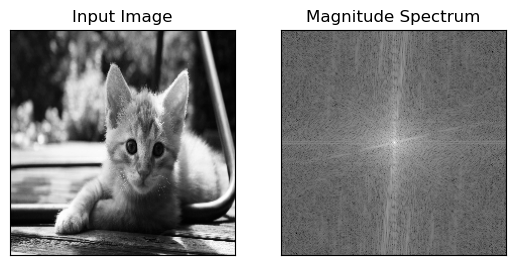

In [2]:

# 20. Visualize magnitude spectrum
# 4. Calculate magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(f_shift))

# 5. Visualization
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])

plt.show()

##--- np.log , .subplot


In [3]:
# 21. Normalize FFT output to image range
# 6. Normalize to 0-255 range
# We use cv2.normalize for this
normalized_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Verify the range
print(f"Min value: {normalized_spectrum.min()}")
print(f"Max value: {normalized_spectrum.max()}")

# Display the normalized version
cv2.imshow('Normalized Magnitude Spectrum', normalized_spectrum)
cv2.waitKey(0)
cv2.destroyAllWindows()


Min value: 0
Max value: 255


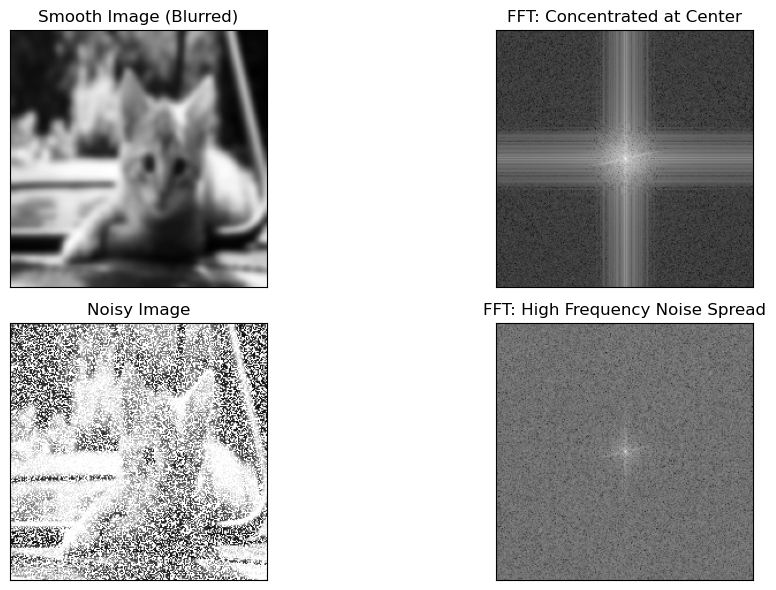

In [4]:
# 22. Compare FFT of:
# ● smooth image
# ● noisy image
# Create Smooth Image (Low Pass Filter effect)
smooth_cat = cv2.GaussianBlur(img, (15, 15), 0)

# Create Noisy Image
noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
noisy_cat = cv2.add(img, noise)

# Compute FFT for both
f_smooth = np.fft.fftshift(np.fft.fft2(smooth_cat))
mag_smooth = 20 * np.log(np.abs(f_smooth) + 1) # added +1 to avoid log(0)

f_noisy = np.fft.fftshift(np.fft.fft2(noisy_cat))
mag_noisy = 20 * np.log(np.abs(f_noisy) + 1)


plt.figure(figsize=(12, 6))

# Smooth Comparison
plt.subplot(221), plt.imshow(smooth_cat, cmap='gray')
plt.title('Smooth Image (Blurred)'), plt.xticks([]), plt.yticks([])

plt.subplot(222), plt.imshow(mag_smooth, cmap='gray')
plt.title('FFT: Concentrated at Center'), plt.xticks([]), plt.yticks([])

# Noisy Comparison
plt.subplot(223), plt.imshow(noisy_cat, cmap='gray')
plt.title('Noisy Image'), plt.xticks([]), plt.yticks([])

plt.subplot(224), plt.imshow(mag_noisy, cmap='gray')
plt.title('FFT: High Frequency Noise Spread'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

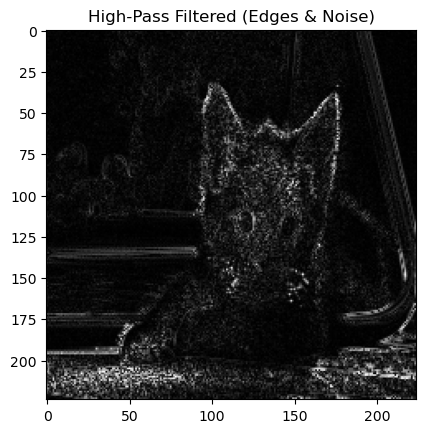

In [5]:
# � Noise Residual
# 23. Apply high-pass filter (kernel-based)

# 1. Apply Laplacian High-Pass Filter
# cv2.CV_64F is used to keep negative values (important for edges)
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# 2. Take the absolute value to make it viewable
hp_filtered = np.uint8(np.absolute(laplacian))

# Visualization
plt.imshow(hp_filtered, cmap='gray')
plt.title('High-Pass Filtered (Edges & Noise)')
plt.show()

##--------- .Laplacian()

In [6]:

# 24. Extract noise by subtracting blurred image
# 1. Create a blurred version (if not already done)
# A small kernel like (3,3) or (5,5) works best to keep edges sharp but isolate noise
blurred_cat = cv2.GaussianBlur(img, (5, 5), 0)

# 2. Subtract the blurred image from the original
# Use cv2.subtract to handle pixel math properly (preventing negative wrap-around)
noise_residual = cv2.subtract(img, blurred_cat)

# 3. Enhance the contrast (Optional, but helps see the noise)
# Since noise is subtle, we multiply it to make it visible
enhanced_noise = cv2.multiply(noise_residual, 5)

print("Noise residual extraction complete.")

##-------- .GaussianBlur() , .subtract(), .multiply()

Noise residual extraction complete.


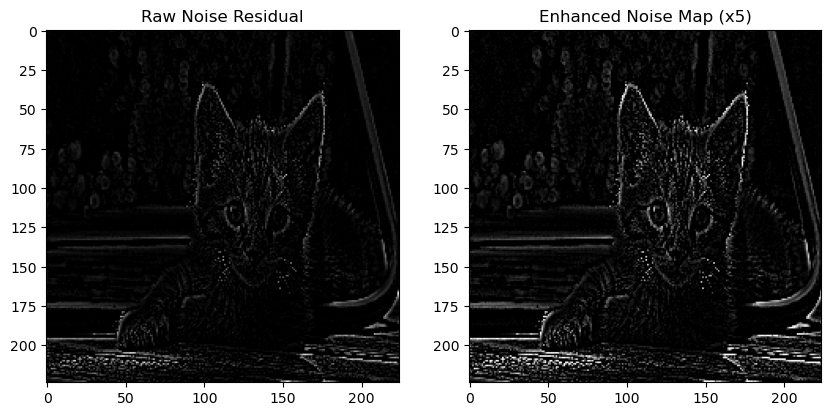

In [7]:
# 25. Visualize noise map
plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(noise_residual, cmap='gray')
plt.title('Raw Noise Residual')

plt.subplot(122), plt.imshow(enhanced_noise, cmap='gray')
plt.title('Enhanced Noise Map (x5)')

plt.show()


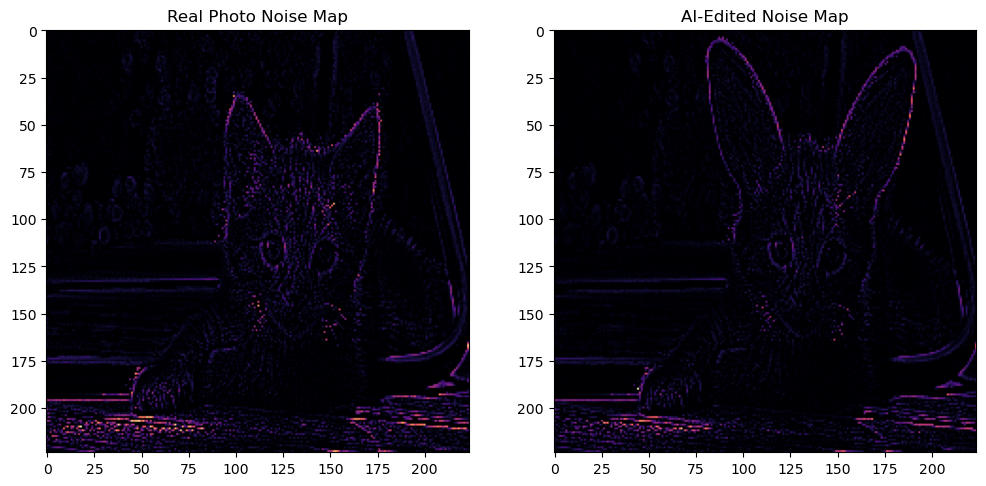

In [9]:
# 26. Compare noise:
# ● real photo
# ● AI-generated image

def get_noise_map(image_path):
    img = cv2.imread(image_path, 0)
    img = cv2.resize(img, (224,224))
    # 1. Use a small blur to isolate high frequencies
    blur = cv2.GaussianBlur(img, (3, 3), 0)
    # 2. Extract residual
    residual = cv2.subtract(img, blur)
    # 3. Normalize for better visibility
    return cv2.normalize(residual, None, 0, 255, cv2.NORM_MINMAX)

# Process both images
real_noise = get_noise_map('cat.jpg')
ai_noise = get_noise_map('ai_edited_cat.png')

# Visualize side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(real_noise, cmap='magma') # Magma helps see density
plt.title('Real Photo Noise Map')

plt.subplot(122), plt.imshow(ai_noise, cmap='magma')
plt.title('AI-Edited Noise Map')
plt.show()

In [ ]:
# � ELA (Error Level Analysis)


In [10]:
# 27. Save image at lower JPEG quality
# 28. Reload compressed image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageChops

# 1. Load the original image
original_path = 'cat.jpg'
original = Image.open(original_path).convert('RGB')

# 2. Save it at a lower quality (Step 27)
# 90-95 is standard for ELA to catch subtle differences
temp_filename = 'temp_compressed.jpg'
original.save(temp_filename, 'JPEG', quality=90)

# 3. Reload the compressed image (Step 28)
compressed = Image.open(temp_filename)

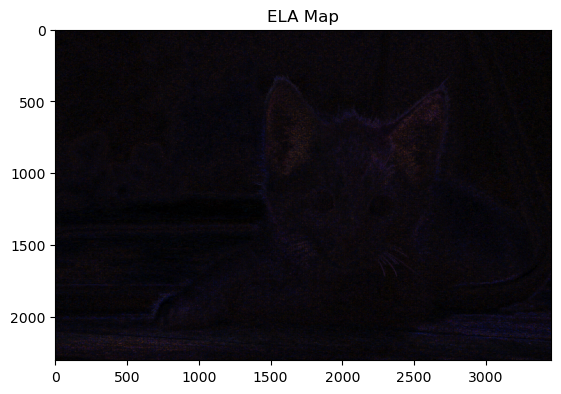

In [12]:

# 29. Compute difference (original - compressed)
# 30. Amplify difference and visualize
# 4. Compute difference (original - compressed) (Step 29)
from PIL import ImageEnhance
# ImageChops.difference finds the absolute difference between pixels
ela_diff = ImageChops.difference(original, compressed)

# 5. Amplify the difference (Step 30)
# The differences are tiny (often 1-5 levels), so we scale them up
extrema = ela_diff.getextrema()
max_diff = max([ex[1] for ex in extrema])
if max_diff == 0:
    max_diff = 1
scale = 255.0 / max_diff

# Create the ELA map by enhancing the brightness
ela_map = ImageEnhance.Brightness(ela_diff).enhance(scale)

plt.imshow(ela_map)
plt.title("ELA Map")
plt.show()


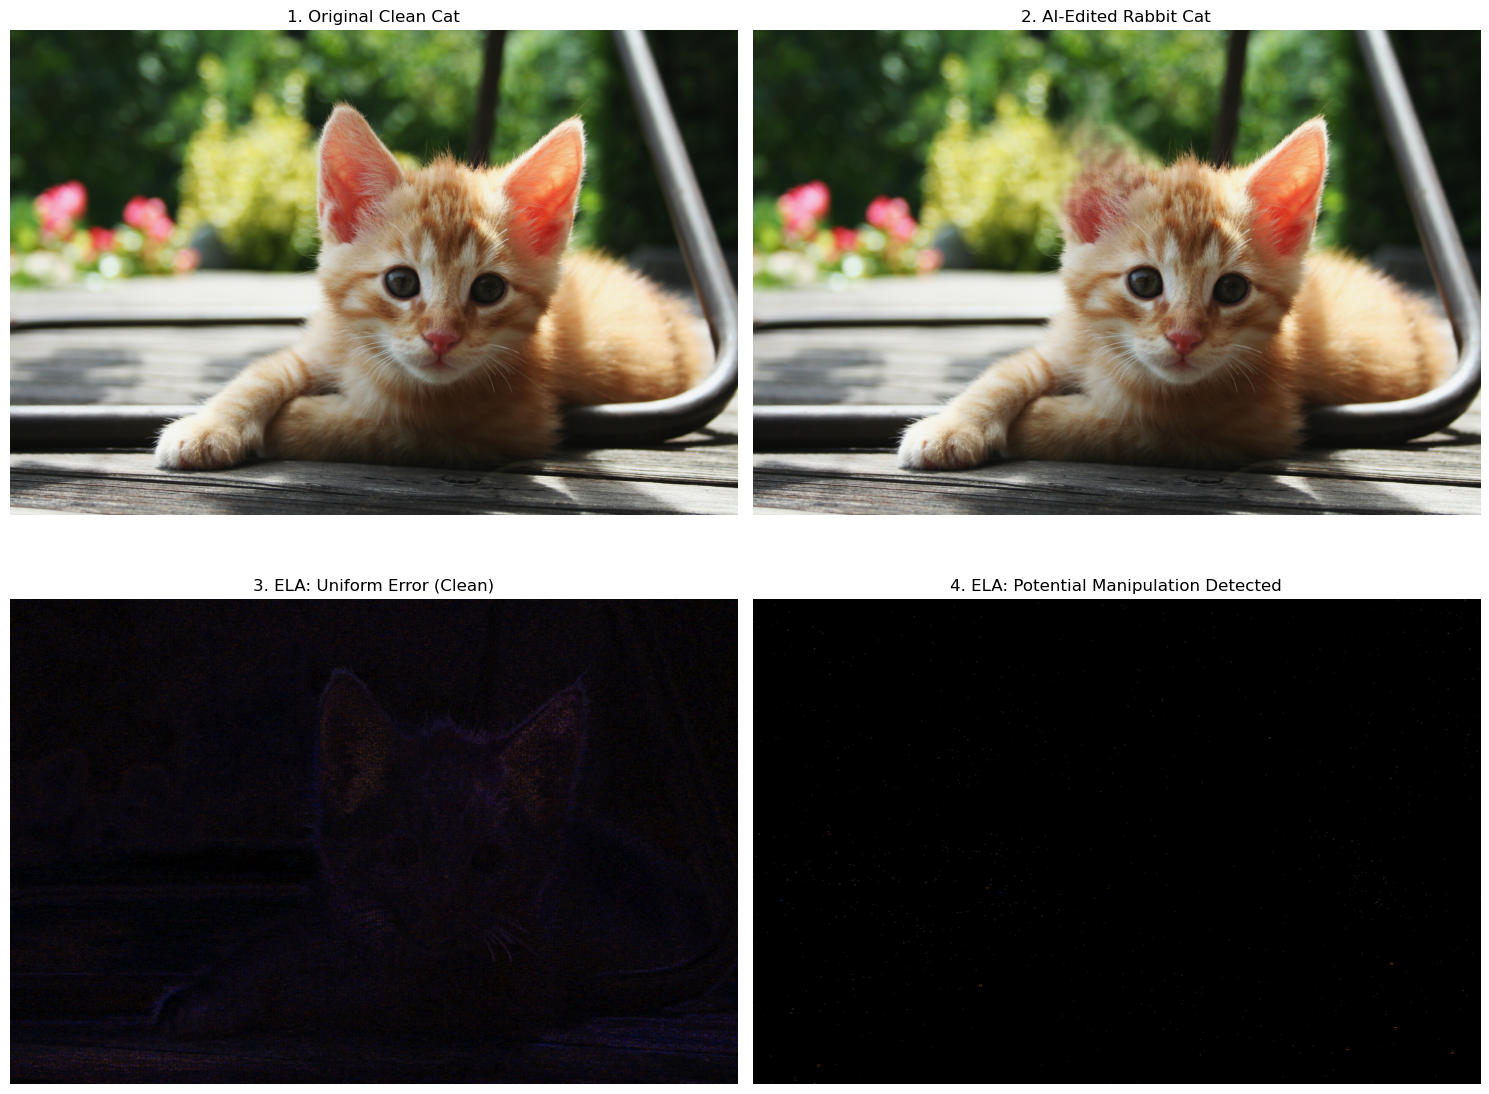

In [17]:
# 31. Compare ELA on:
# ● clean image
# ● edited image

from PIL import Image, ImageChops, ImageEnhance
import matplotlib.pyplot as plt

def get_ela(image_path, quality=90):
    """Computes the ELA map for a given image path."""
    original = Image.open(image_path).convert('RGB')
    
    # Save at temporary compression
    temp_file = 'temp_ela.jpg'
    original.save(temp_file, 'JPEG', quality=quality)
    compressed = Image.open(temp_file)
    
    # Calculate difference
    diff = ImageChops.difference(original, compressed)
    
    # Amplify the result
    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0: max_diff = 1
    scale = 255.0 / max_diff
    
    return ImageEnhance.Brightness(diff).enhance(scale)

# --- Process both images ---
# Make sure these filenames match your local files!
clean_ela = get_ela('cat.jpg')
edited_ela = get_ela('cat2.jpg')

# --- Plotting the Comparison ---
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# Row 1: The Images
ax[0, 0].imshow(Image.open('cat.jpg'))
ax[0, 0].set_title("1. Original Clean Cat")
ax[0, 1].imshow(Image.open('cat2.jpg'))
ax[0, 1].set_title("2. AI-Edited Rabbit Cat")

# Row 2: The ELA Results
ax[1, 0].imshow(clean_ela)
ax[1, 0].set_title("3. ELA: Uniform Error (Clean)")
ax[1, 1].imshow(edited_ela)
ax[1, 1].set_title("4. ELA: Potential Manipulation Detected")

for a in ax.flat:
    a.axis('off')

plt.tight_layout()
plt.show()